<a href="https://colab.research.google.com/github/snehaskarun22/mlt/blob/main/mlt_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/sample_data/retail_store_inventory.csv")

print("\n--- DATA LOADED FOR TRAINING ---")
print(df.head())

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Sort data
df = df.sort_values(["Store ID", "Product ID", "Date"])

# Lag features
df["Units Sold_lag1"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(1)
df["Units Sold_lag2"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(2)
df["Units Sold_lag3"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(3)

df = df.fillna(0)

print("\n--- FEATURES CREATED ---")
print(df.head())
df.describe()


--- DATA LOADED FOR TRAINING ---
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0             

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing,Year,Month,DayOfWeek,Units Sold_lag1,Units Sold_lag2,Units Sold_lag3
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077,2022.502052,6.518468,3.002736,136.283694,136.130369,135.950397
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000,2022.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000,2022.000000,4.000000,1.000000,48.000000,48.000000,48.000000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000,2023.000000,7.000000,3.000000,107.000000,107.000000,107.000000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000,2023.000000,10.000000,5.000000,202.000000,202.000000,202.000000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000,2024.000000,12.000000,6.000000,499.000000,499.000000,499.000000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408,0.502728,3.451564,2.003429,108.961973,109.024687,109.074506


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/sample_data/retail_store_inventory.csv")

print("\n--- DATA LOADED FOR TRAINING ---")
print(df.head())

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Sort data
df = df.sort_values(["Store ID", "Product ID", "Date"])

# Lag features
df["Units Sold_lag1"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(1)
df["Units Sold_lag2"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(2)
df["Units Sold_lag3"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(3)

df = df.fillna(0)

print("\n--- FEATURES CREATED ---")
print(df.head())
df.describe()


--- DATA LOADED FOR TRAINING ---
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0             

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing,Year,Month,DayOfWeek,Units Sold_lag1,Units Sold_lag2,Units Sold_lag3
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077,2022.502052,6.518468,3.002736,136.283694,136.130369,135.950397
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000,2022.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000,2022.000000,4.000000,1.000000,48.000000,48.000000,48.000000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000,2023.000000,7.000000,3.000000,107.000000,107.000000,107.000000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000,2023.000000,10.000000,5.000000,202.000000,202.000000,202.000000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000,2024.000000,12.000000,6.000000,499.000000,499.000000,499.000000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408,0.502728,3.451564,2.003429,108.961973,109.024687,109.074506


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TIME-BASED TRAIN–TEST SPLIT
split_date = "2023-01-01"

train = df[df["Date"] < split_date]
test  = df[df["Date"] >= split_date]

print("\nTraining rows:", len(train))
print("Testing rows :", len(test))

y_train = train["Units Sold"]
y_test = test["Units Sold"]

# Drop target + date
X_train = train.drop(["Units Sold", "Date"], axis=1)
X_test  = test.drop(["Units Sold", "Date"], axis=1)

# Categorical features
categorical_cols = [
    "Store ID","Product ID","Category","Region",
    "Weather Condition","Holiday/Promotion","Seasonality"
]

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

# LIGHTGBM REGRESSOR
model = lgb.LGBMRegressor(
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# Model predictions
pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("\n--- MODEL PERFORMANCE ---")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Training rows: 36500
Testing rows : 36600
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2037
[LightGBM] [Info] Number of data points in the train set: 36500, number of used features: 18
[LightGBM] [Info] Start training from score 136.756822

--- MODEL PERFORMANCE ---
MAE : 7.22780704098773
RMSE: 8.465280906520897
R²  : 0.9939443586775697



--- FORECAST (first 5 rows) ---
        Date Store ID Product ID  Predicted Units Sold
0 2024-01-02     S001      P0001              3.802467
1 2024-01-03     S001      P0001              3.807964
2 2024-01-04     S001      P0001              4.578317
3 2024-01-05     S001      P0001              4.576625
4 2024-01-06     S001      P0001              4.576625


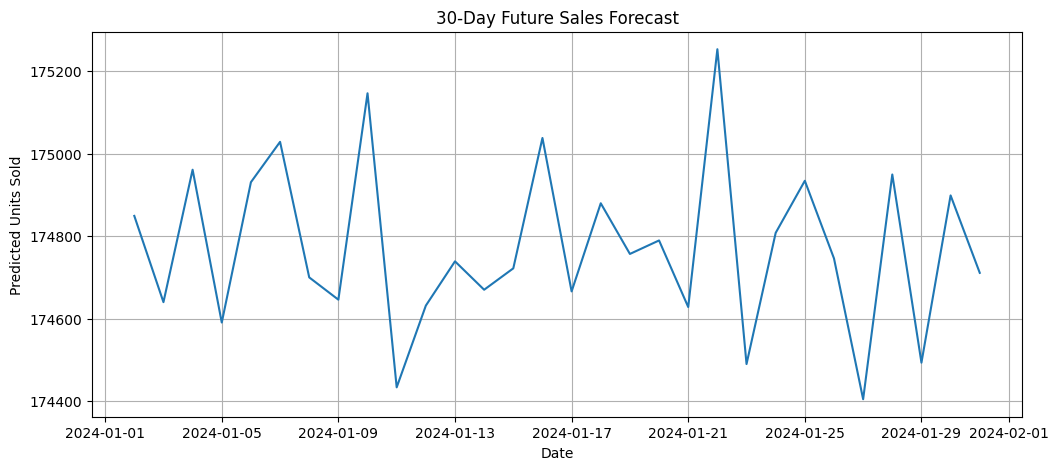

In [ ]:
# Predict future sales
future_pred = model.predict(future_clean)

# FIX: Use future_df dates (matches length of predictions)
forecast = pd.DataFrame({
    "Date": future_df["Date"].values,
    "Store ID": future_df["Store ID"].values,
    "Product ID": future_df["Product ID"].values,
    "Predicted Units Sold": future_pred
})

print("\n--- FORECAST (first 5 rows) ---")
print(forecast.head())

# Plot (aggregation to daily)
daily_forecast = forecast.groupby("Date")["Predicted Units Sold"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily_forecast["Date"], daily_forecast["Predicted Units Sold"])
plt.title("30-Day Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Units Sold")
plt.grid()
plt.show()


In [ ]:
num_products = df['Product ID'].nunique()
print(f"There are {num_products} unique products in the dataset.")

NameError: name 'df' is not defined

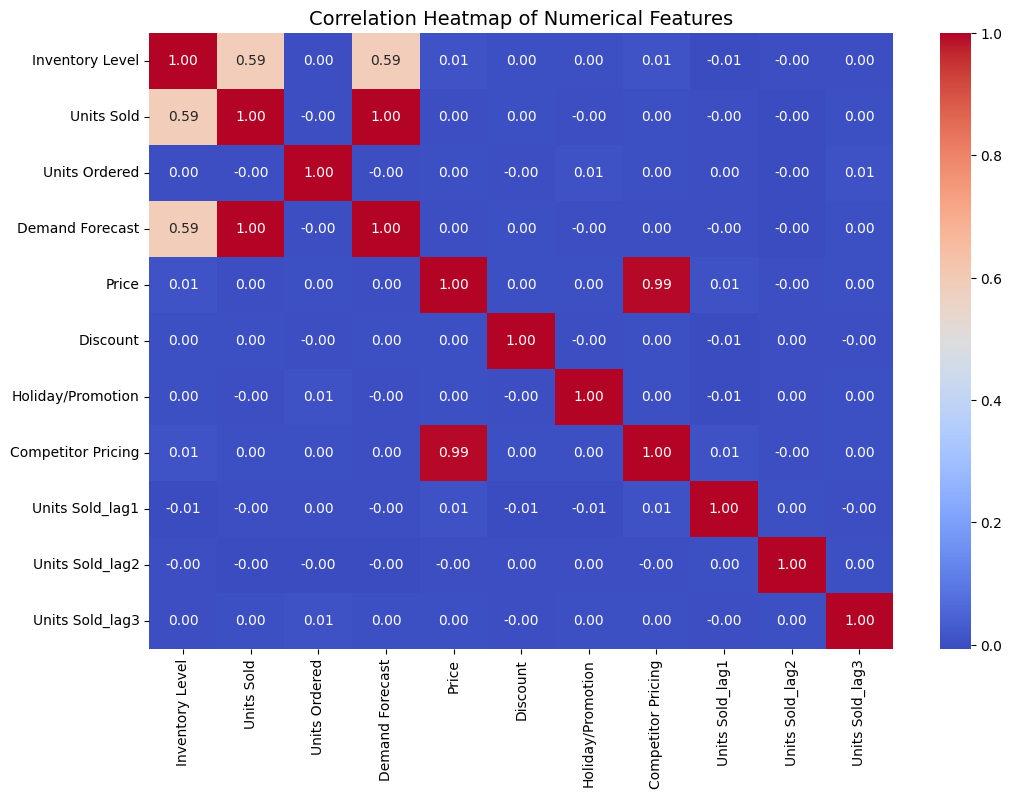

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()
